In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.makedirs('../models/plots', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
import lightgbm as lgb

from src.features import build_features
from src.preprocessing import prepare_data

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('✅ Бібліотеки завантажено')

✅ Бібліотеки завантажено


## Крок 1: Завантаження та feature engineering

In [2]:
print('📥 Завантаження та побудова ознак...')
df = build_features(use_local=True)
print(f'\n✅ Матриця ознак: {df.shape[0]:,} рядків × {df.shape[1]} колонок')
print(f'Рівень дефолту: {df["target"].mean():.2%}')

📥 Завантаження та побудова ознак...
📂 Завантаження таблиць...
✅ 'application_train' з parquet: 307,511 рядків, 122 колонок
✅ 'bureau' з parquet: 1,716,428 рядків, 17 колонок
✅ 'bureau_balance' з parquet: 54,599,850 рядків, 3 колонок
✅ 'previous_application' з parquet: 1,670,214 рядків, 37 колонок
✅ 'pos_cash_balance' з parquet: 10,001,358 рядків, 8 колонок
✅ 'installments_payments' з parquet: 13,605,401 рядків, 8 колонок
✅ 'credit_card_balance' з parquet: 3,840,312 рядків, 24 колонок

🔧 Побудова ознак...
  + bureau                    11 ознак
  + bureau_balance            4 ознак
  + previous_application      11 ознак
  + pos_cash                  8 ознак
  + installments              9 ознак
  + credit_card               10 ознак

✅ Матриця ознак: 307,511 рядків × 175 колонок

✅ Матриця ознак: 307,511 рядків × 175 колонок
Рівень дефолту: 8.07%


## Крок 2: Препроцесинг

In [3]:
X, y, num_cols, cat_cols, preprocessor = prepare_data(df)

print(f'\n📊 Розміри даних:')
print(f'  X: {X.shape}')
print(f'  y: {y.shape}')
print(f'  Числових ознак: {len(num_cols)}')
print(f'  Категоріальних ознак: {len(cat_cols)}')
print(f'  Клас 0 (без дефолту): {(y==0).sum():,}')
print(f'  Клас 1 (дефолт): {(y==1).sum():,}')

Features: 157 numeric, 16 categorical
Target distribution: {0: 282686, 1: 24825}

📊 Розміри даних:
  X: (307511, 173)
  y: (307511,)
  Числових ознак: 157
  Категоріальних ознак: 16
  Клас 0 (без дефолту): 282,686
  Клас 1 (дефолт): 24,825


## Крок 3: Cross-Validation

In [4]:
model_lgb = lgb.LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 31,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_lgb),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []
fold_probs  = []
fold_true   = []

print('🔄 5-fold Cross-Validation...')
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_prob)
    fold_scores.append(auc)
    fold_probs.append(y_prob)
    fold_true.append(y_val.values)

    print(f'  Fold {fold}: ROC-AUC = {auc:.4f}')

print(f'\n✅ CV Mean ROC-AUC: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')

🔄 5-fold Cross-Validation...
  Fold 1: ROC-AUC = 0.7746
  Fold 2: ROC-AUC = 0.7727
  Fold 3: ROC-AUC = 0.7754
  Fold 4: ROC-AUC = 0.7770
  Fold 5: ROC-AUC = 0.7722

✅ CV Mean ROC-AUC: 0.7744 ± 0.0018


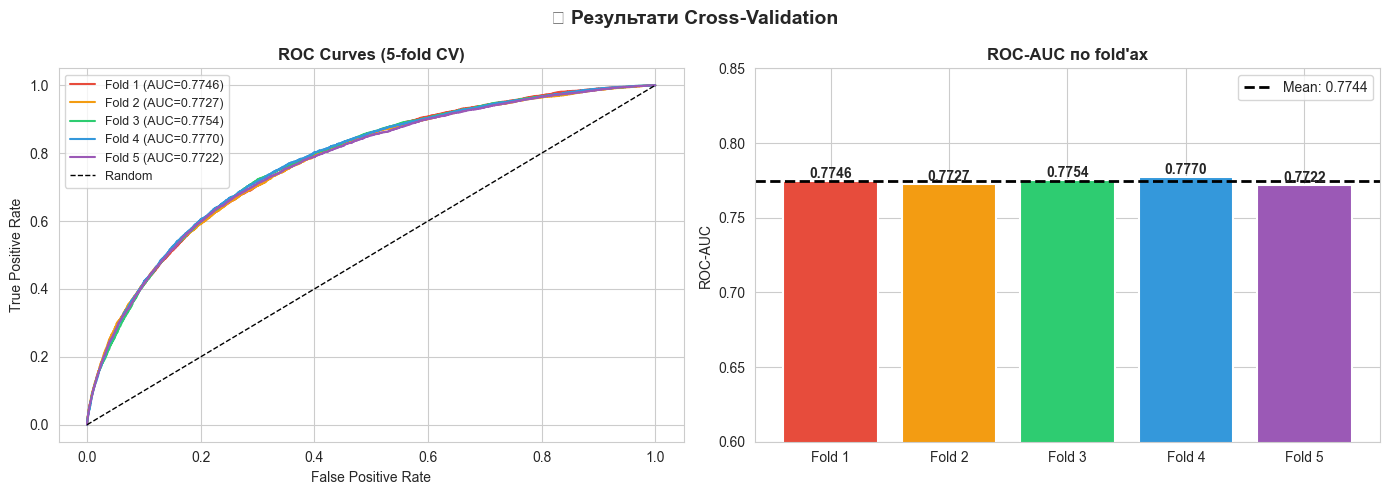

In [5]:
# ROC кривi для кожного fold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_folds = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']

for i, (y_true, y_prob, color) in enumerate(zip(fold_true, fold_probs, colors_folds)):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = fold_scores[i]
    axes[0].plot(fpr, tpr, color=color, lw=1.5, label=f'Fold {i+1} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (5-fold CV)', fontweight='bold')
axes[0].legend(fontsize=9)

# Scores bar
bars = axes[1].bar([f'Fold {i+1}' for i in range(5)], fold_scores,
                   color=colors_folds, edgecolor='white', linewidth=1.5)
axes[1].axhline(np.mean(fold_scores), color='black', linestyle='--', lw=2,
                label=f'Mean: {np.mean(fold_scores):.4f}')
axes[1].set_ylim(0.6, 0.85)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC по fold\'ах', fontweight='bold')
axes[1].legend()
for bar, score in zip(bars, fold_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{score:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('📈 Результати Cross-Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/cv_results.png', bbox_inches='tight', dpi=150)
plt.show()

## Крок 4: Фінальна модель та метрики

In [6]:
from sklearn.model_selection import train_test_split

# Train/test split для фінальних метрик
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('🏋️ Тренування фінальної моделі...')
pipeline.fit(X_train, y_train)

y_prob_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= 0.5).astype(int)

auc_test = roc_auc_score(y_test, y_prob_test)
ap_test  = average_precision_score(y_test, y_prob_test)

print(f'\n📊 Метрики на тестовому наборі:')
print(f'  ROC-AUC: {auc_test:.4f}')
print(f'  Average Precision: {ap_test:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_test, target_names=['Без дефолту', 'Дефолт']))

🏋️ Тренування фінальної моделі...

📊 Метрики на тестовому наборі:
  ROC-AUC: 0.7769
  Average Precision: 0.2695

Classification Report:
              precision    recall  f1-score   support

 Без дефолту       0.96      0.79      0.87     56538
      Дефолт       0.20      0.61      0.30      4965

    accuracy                           0.77     61503
   macro avg       0.58      0.70      0.59     61503
weighted avg       0.90      0.77      0.82     61503



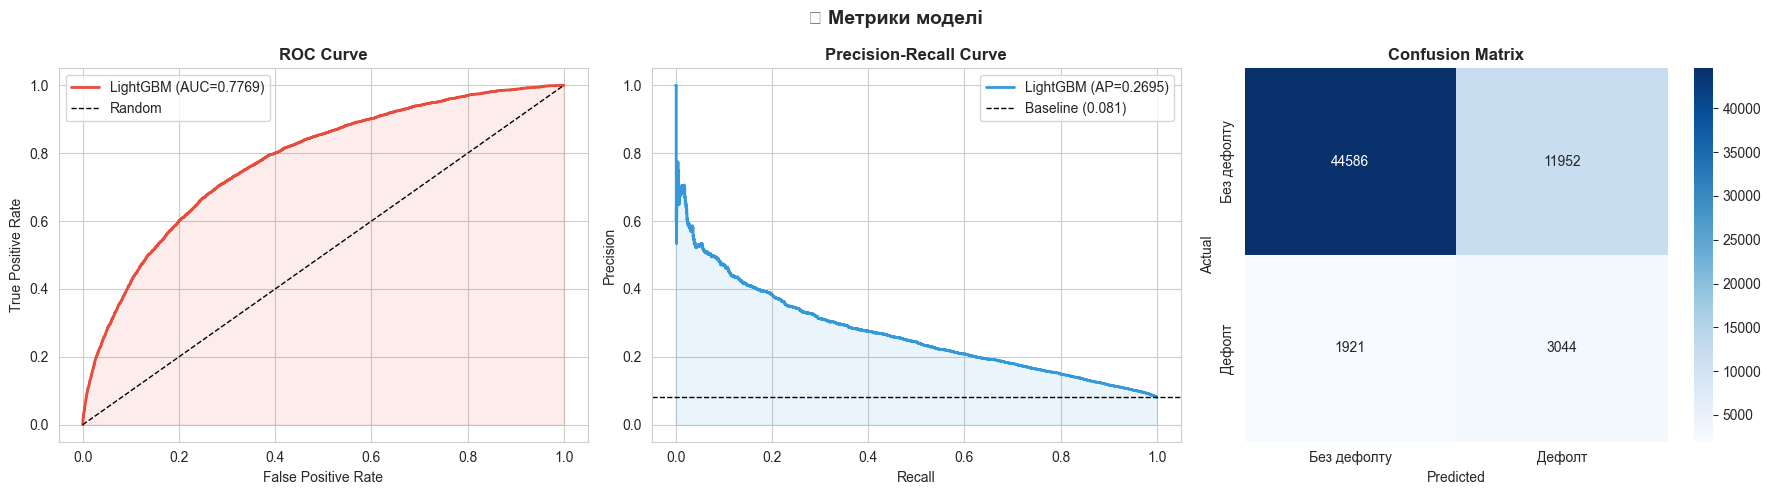

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_test)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'LightGBM (AUC={auc_test:.4f})')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_test)
axes[1].plot(recall, precision, color='#3498db', lw=2, label=f'LightGBM (AP={ap_test:.4f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='#3498db')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Без дефолту', 'Дефолт'],
            yticklabels=['Без дефолту', 'Дефолт'])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.suptitle('📊 Метрики моделі', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/model_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

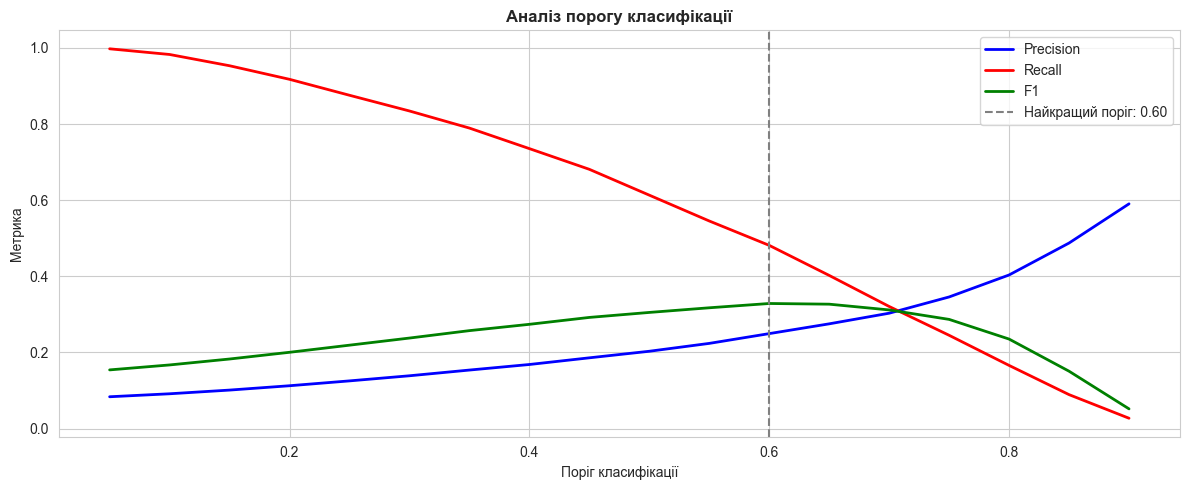

Оптимальний поріг (max F1): 0.60


In [8]:
# Аналіз порогу
thresholds = np.arange(0.05, 0.95, 0.05)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (y_prob_test >= thresh).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

best_thresh = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, precisions, 'b-', lw=2, label='Precision')
ax.plot(thresholds, recalls, 'r-', lw=2, label='Recall')
ax.plot(thresholds, f1s, 'g-', lw=2, label='F1')
ax.axvline(best_thresh, color='gray', linestyle='--', lw=1.5,
           label=f'Найкращий поріг: {best_thresh:.2f}')
ax.set_xlabel('Поріг класифікації')
ax.set_ylabel('Метрика')
ax.set_title('Аналіз порогу класифікації', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../models/plots/threshold_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Оптимальний поріг (max F1): {best_thresh:.2f}')

## Крок 5: Важливість ознак

✅ feature_importance.csv збережено


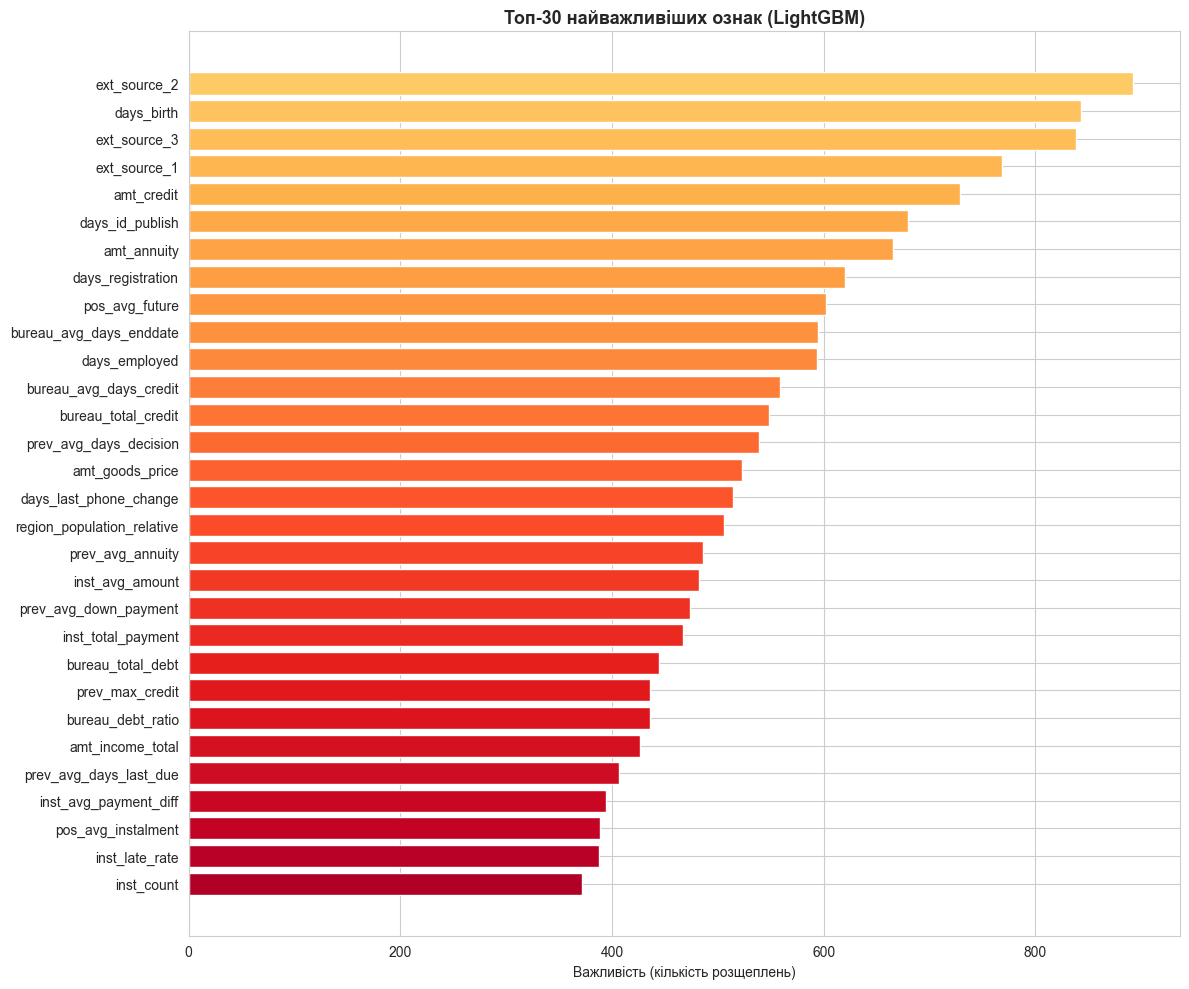


Топ-15 ознак:
                feature  importance
           ext_source_2         892
             days_birth         843
           ext_source_3         838
           ext_source_1         768
             amt_credit         729
        days_id_publish         680
            amt_annuity         665
      days_registration         620
         pos_avg_future         602
bureau_avg_days_enddate         595
          days_employed         594
 bureau_avg_days_credit         559
    bureau_total_credit         548
 prev_avg_days_decision         539
        amt_goods_price         523


In [9]:
# Feature importance
model = pipeline.named_steps['model']
feat_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.to_csv('../models/feature_importance.csv', index=False)
print('✅ feature_importance.csv збережено')

# Plot top 30
top30 = importance_df.head(30)
fig, ax = plt.subplots(figsize=(12, 10))

colors_imp = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top30))[::-1])
bars = ax.barh(top30['feature'][::-1], top30['importance'][::-1], color=colors_imp)
ax.set_xlabel('Важливість (кількість розщеплень)')
ax.set_title('Топ-30 найважливіших ознак (LightGBM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nТоп-15 ознак:')
print(importance_df.head(15)[['feature', 'importance']].to_string(index=False))

## Крок 6: SHAP пояснення

In [10]:
import shap

# Трансформуємо дані для SHAP
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feat_names)

print('🔍 Обчислення SHAP values (вибірка 1000 рядків)...')
explainer = shap.TreeExplainer(model)

sample_idx = np.random.choice(len(X_test_df), min(1000, len(X_test_df)), replace=False)
X_shap = X_test_df.iloc[sample_idx]
shap_values = explainer.shap_values(X_shap)

# Для бінарної класифікації беремо клас 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print('✅ SHAP values обчислено')

🔍 Обчислення SHAP values (вибірка 1000 рядків)...
✅ SHAP values обчислено


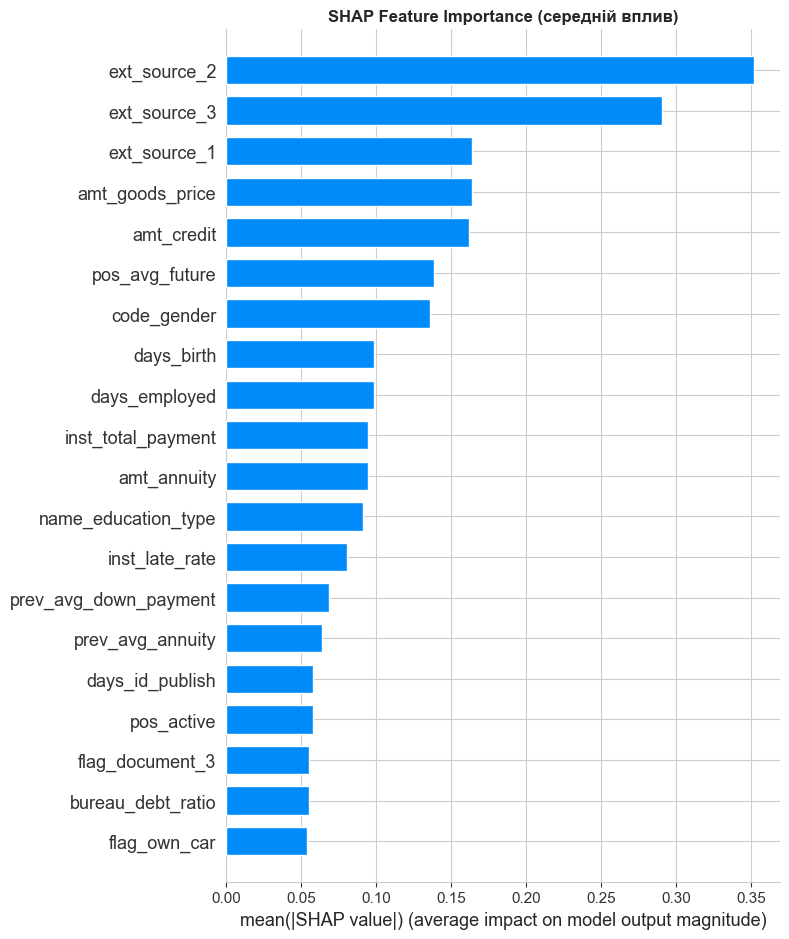

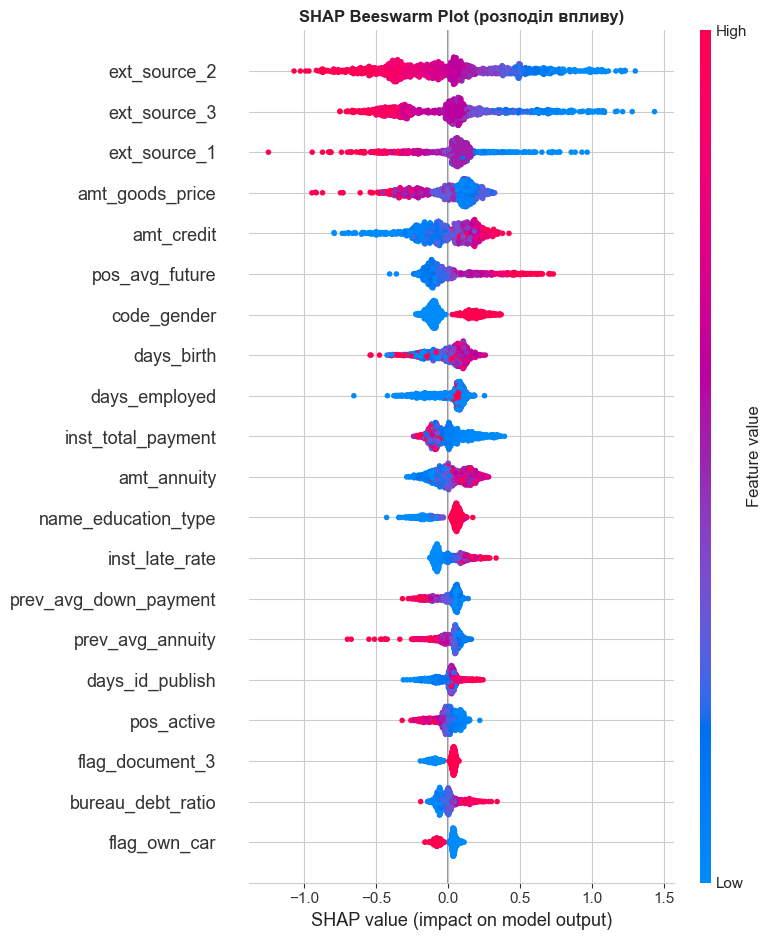

In [11]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(sv, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance (середній вплив)', fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# SHAP Beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(sv, X_shap, max_display=20, show=False)
plt.title('SHAP Beeswarm Plot (розподіл впливу)', fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

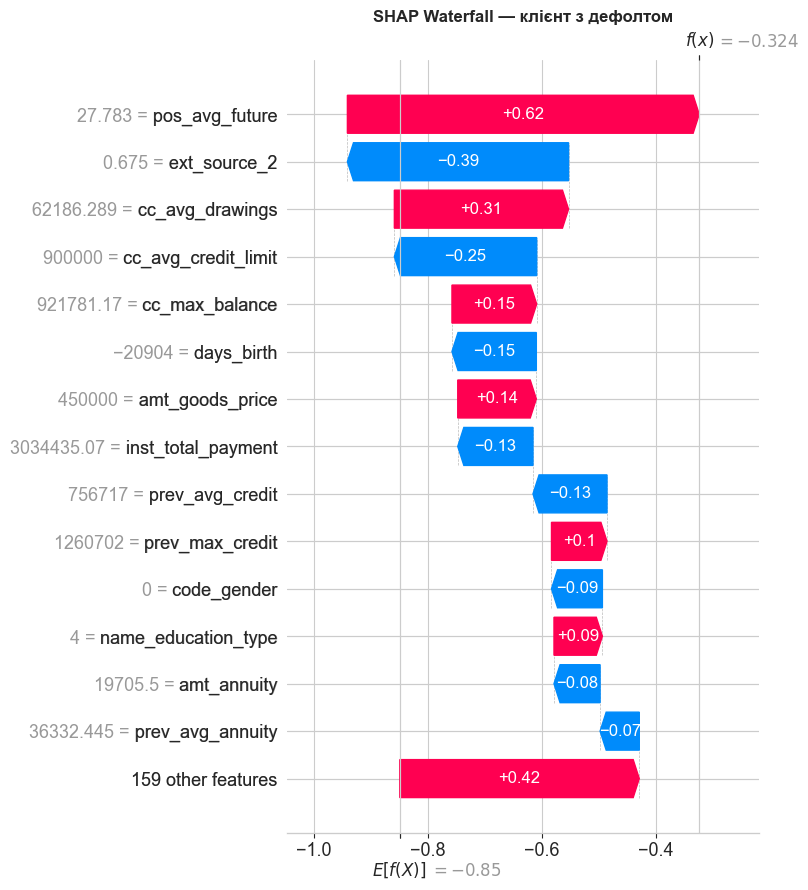

In [12]:
# SHAP Waterfall для одного клієнта (дефолт)
default_idx = np.where(y_test.values[sample_idx] == 1)[0]
if len(default_idx) > 0:
    idx = default_idx[0]
    shap_exp = shap.Explanation(
        values=sv[idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=X_shap.iloc[idx].values,
        feature_names=feat_names.tolist()
    )
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title('SHAP Waterfall — клієнт з дефолтом', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../models/plots/shap_waterfall_default.png', bbox_inches='tight', dpi=150)
    plt.show()

## Крок 7: Збереження моделі

In [13]:
os.makedirs('../models', exist_ok=True)

# Тренуємо фінальну модель на всіх даних
print('🏋️ Тренування фінальної моделі на всьому датасеті...')
pipeline.fit(X, y)

model_path = '../models/credit_scoring_lgbm.pkl'
joblib.dump(pipeline, model_path)
print(f'✅ Модель збережена: {model_path}')

# Metadata
import json
metadata = {
    'model_type': 'LightGBMClassifier',
    'cv_auc_mean': float(np.mean(fold_scores)),
    'cv_auc_std': float(np.std(fold_scores)),
    'test_auc': float(auc_test),
    'test_avg_precision': float(ap_test),
    'optimal_threshold': float(best_thresh),
    'n_features': int(X.shape[1]),
    'n_train_samples': int(X.shape[0]),
    'feature_names': list(feat_names),
    'top_features': importance_df.head(15)['feature'].tolist()
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Метадані збережені: ../models/model_metadata.json')

print('\n' + '='*50)
print('  ✅ МОДЕЛЬ ГОТОВА!')
print('='*50)
print(f'  CV ROC-AUC: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')
print(f'  Test ROC-AUC: {auc_test:.4f}')
print(f'  Оптимальний поріг: {best_thresh:.2f}')
print(f'  Кількість ознак: {X.shape[1]}')

🏋️ Тренування фінальної моделі на всьому датасеті...
✅ Модель збережена: ../models/credit_scoring_lgbm.pkl
✅ Метадані збережені: ../models/model_metadata.json

  ✅ МОДЕЛЬ ГОТОВА!
  CV ROC-AUC: 0.7744 ± 0.0018
  Test ROC-AUC: 0.7769
  Оптимальний поріг: 0.60
  Кількість ознак: 173


## Крок 8: Аналіз ризику за скором

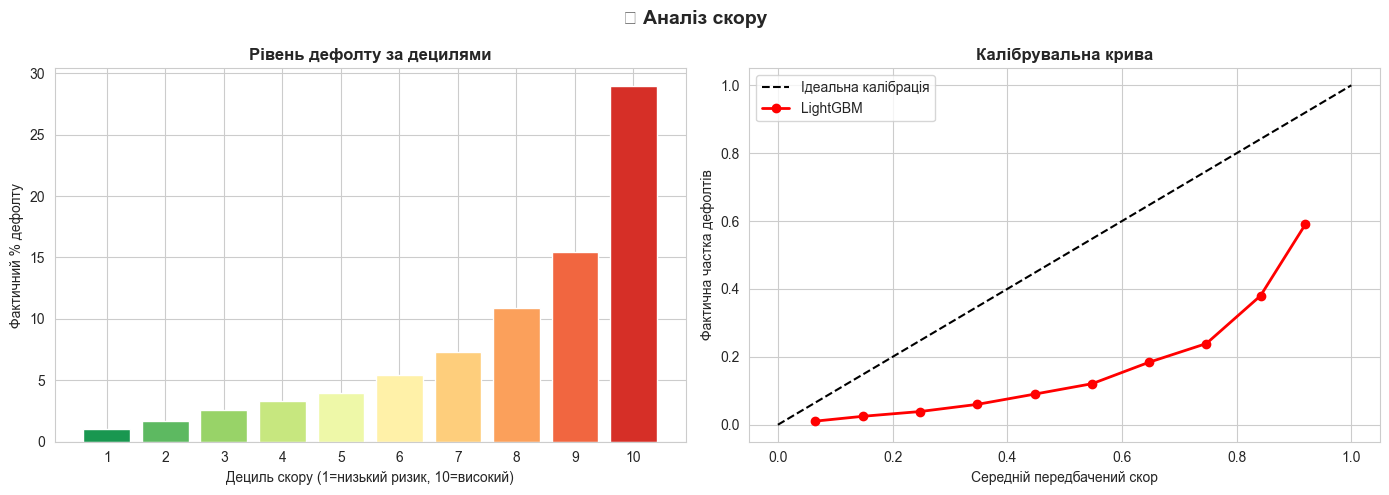

Аналіз за децилями:
 score_bin  count  actual_defaults  avg_prob  default_rate
         0   6151               65  0.056803      0.010567
         1   6150              106  0.108844      0.017236
         2   6150              157  0.155618      0.025528
         3   6150              205  0.204719      0.033333
         4   6151              246  0.259661      0.039993
         5   6150              336  0.324888      0.054634
         6   6150              450  0.402934      0.073171
         7   6150              668  0.494536      0.108618
         8   6150              951  0.608641      0.154634
         9   6151             1781  0.772818      0.289546


In [14]:
# Аналіз за децилями скору
score_analysis = pd.DataFrame({
    'probability': y_prob_test,
    'actual': y_test.values
})

score_analysis['score_bin'] = pd.qcut(score_analysis['probability'], q=10, labels=False)
decile_stats = score_analysis.groupby('score_bin').agg(
    count=('actual', 'count'),
    actual_defaults=('actual', 'sum'),
    avg_prob=('probability', 'mean'),
    default_rate=('actual', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by decile
colors_decile = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(decile_stats)))
bars = axes[0].bar(decile_stats['score_bin'] + 1, decile_stats['default_rate'] * 100,
                   color=colors_decile)
axes[0].set_xlabel('Дециль скору (1=низький ризик, 10=високий)')
axes[0].set_ylabel('Фактичний % дефолту')
axes[0].set_title('Рівень дефолту за децилями', fontweight='bold')
axes[0].set_xticks(range(1, 11))

# Calibration
fraction_of_positives, mean_predicted = calibration_curve(y_test, y_prob_test, n_bins=10)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Ідеальна калібрація')
axes[1].plot(mean_predicted, fraction_of_positives, 'r-o', lw=2, label='LightGBM')
axes[1].set_xlabel('Середній передбачений скор')
axes[1].set_ylabel('Фактична частка дефолтів')
axes[1].set_title('Калібрувальна крива', fontweight='bold')
axes[1].legend()

plt.suptitle('🎯 Аналіз скору', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/score_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('Аналіз за децилями:')
print(decile_stats.to_string(index=False))